In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.linear_model import LinearRegression
lr = LinearRegression()


In [2]:
data=pd.read_csv('Housing.csv')

In [3]:
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [4]:
data.mainroad = data.mainroad.apply(lambda x: 1 if x=='yes' else 0)
data.guestroom = data.guestroom.apply(lambda x: 1 if x=='yes' else 0)
data.hotwaterheating = data.hotwaterheating.apply(lambda x: 1 if x=='yes' else 0)
data.airconditioning = data.airconditioning.apply(lambda x: 1 if x=='yes' else 0)
data.prefarea = data.prefarea.apply(lambda x: 1 if x=='yes' else 0)
data.furnishingstatus = data.furnishingstatus.apply(lambda x: 1 if x=='furnished' else 0)
data.basement = data.basement.apply(lambda x: 1 if x=='yes' else 0)

In [5]:
data.corr()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
price,1.000000,0.535997,0.366494,0.517545,0.420712,0.296898,0.255517,0.187057,0.093073,0.452954,0.384394,0.329777,0.229350
area,0.535997,1.000000,0.151858,0.193820,0.083996,0.288874,0.140297,0.047417,-0.009229,0.222393,0.352980,0.234779,0.145772
bedrooms,0.366494,0.151858,1.000000,0.373930,0.408564,-0.012033,0.080549,0.097312,0.046049,0.160603,0.139270,0.079023,0.079054
bathrooms,0.517545,0.193820,0.373930,1.000000,0.326165,0.042398,0.126469,0.102106,0.067159,0.186915,0.177496,0.063472,0.108139
stories,0.420712,0.083996,0.408564,0.326165,1.000000,0.121706,0.043538,-0.172394,0.018847,0.293602,0.045547,0.044425,0.093176
mainroad,0.296898,0.288874,-0.012033,0.042398,0.121706,1.000000,0.092337,0.044002,-0.011781,0.105423,0.204433,0.199876,0.129971
guestroom,0.255517,0.140297,0.080549,0.126469,0.043538,0.092337,1.000000,0.372066,-0.010308,0.138179,0.037466,0.160897,0.099721
basement,0.187057,0.047417,0.097312,0.102106,-0.172394,0.044002,0.372066,1.000000,0.004385,0.047341,0.051497,0.228083,0.069852
hotwaterheating,0.093073,-0.009229,0.046049,0.067159,0.018847,-0.011781,-0.010308,0.004385,1.000000,-0.130023,0.067864,-0.059411,-0.008472
airconditioning,0.452954,0.222393,0.160603,0.186915,0.293602,0.105423,0.138179,0.047341,-0.130023,1.000000,0.159173,0.117382,0.160994


In [6]:
data.drop(['mainroad','guestroom','hotwaterheating','airconditioning','prefarea','furnishingstatus'],axis=1,inplace=True)

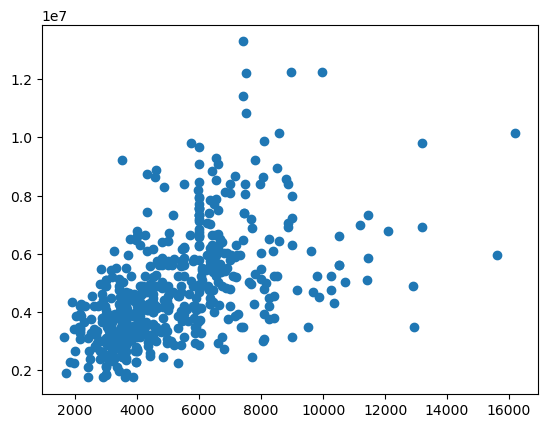

In [7]:
plt.scatter(x=data.area, y=data.price)

In [8]:
X=data.drop('price',axis=1)
y=data['price']

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [10]:
lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [11]:
lr.intercept_

np.float64(-180838.7411982501)

In [12]:
lr.coef_

array([3.26068876e+02, 6.96224919e+04, 1.09423733e+06, 6.21565920e+05,
       8.55678210e+05, 4.00782931e+05])

In [15]:
y_pred_train = lr.predict(X_train)

In [16]:
from sklearn.metrics import mean_squared_error, r2_score

In [17]:
mean_squared_error(y_train, y_pred_train)

1166591354793.1797

In [19]:
r2_score(y_train,y_pred_train)

0.6286591836692421

In [20]:
lr.score(X_test,y_test)

0.5207297071776273